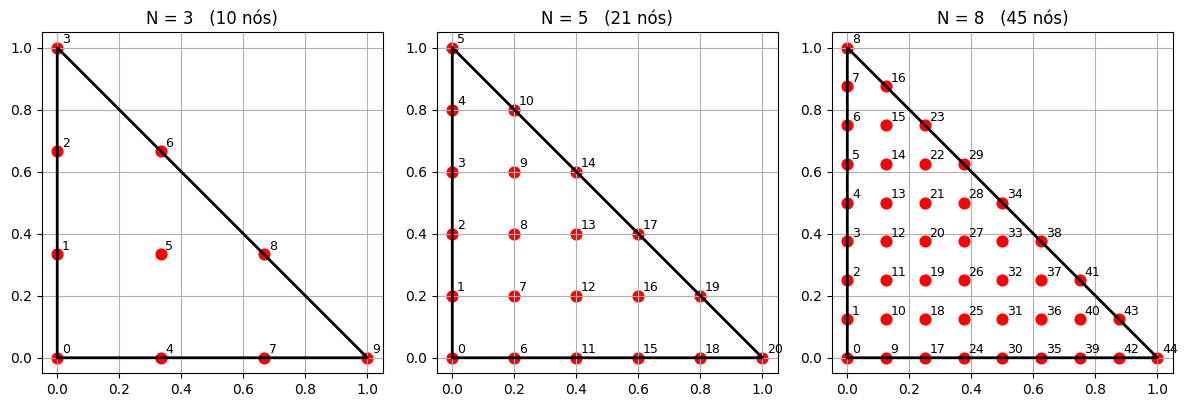

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def triangle_nodes(N):
    x = []
    y = []

    for i in range(N + 1):
        for j in range(N + 1 - i):
            x.append(i / N)
            y.append(j / N)

    return np.array(x), np.array(y)


def plot_triangle_nodes(N, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    x, y = triangle_nodes(N)

    ax.scatter(x, y, color='red', s=60)

    # Numeração dos nós
    for k in range(len(x)):
        ax.text(x[k] + 0.015,
                y[k] + 0.015,
                str(k),
                fontsize=9)

    # Contorno do triângulo
    tri_x = [0, 1, 0, 0]
    tri_y = [0, 0, 1, 0]

    ax.plot(tri_x, tri_y, 'k', lw=2)

    ax.set_aspect('equal')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"N = {N}   ({len(x)} nós)")
    ax.grid(True)


fig, axs = plt.subplots(1, 3, figsize=(12,6))

plot_triangle_nodes(3, axs[0])
plot_triangle_nodes(5, axs[1])
plot_triangle_nodes(8, axs[2])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def triangle_nodes(N):
    pts = []

    for i in range(N + 1):
        for j in range(N + 1 - i):
            x = i / N
            y = j / N
            pts.append((x, y))

    return np.array(pts)


def monomial_exponents(N):
    exp = []

    for d in range(N + 1):
        for i in range(d + 1):
            j = d - i
            exp.append((i, j))

    return exp


def vandermonde(N):

    pts = triangle_nodes(N)
    exp = monomial_exponents(N)
    V = np.zeros((len(pts), len(exp)))

    for r, (x, y) in enumerate(pts):
        for c, (i, j) in enumerate(exp):
            V[r, c] = x**i * y**j

    return V


for N in [3, 5, 8]:

    V = vandermonde(N)

    cond = np.linalg.cond(V)

    print(f"N = {N}")
    print(f"Número de nós = {V.shape[0]}")
    print(f"Cond(V) = {cond:.3e}")
    print()

N = 3
Número de nós = 10
Cond(V) = 3.124e+02

N = 5
Número de nós = 21
Cond(V) = 3.951e+04

N = 8
Número de nós = 45
Cond(V) = 7.061e+07

